In [2]:
#1) Import Pandas, Matplotlib, Numpy, Statsmodels, Seaborn, and Scipy.  Do not use any other libraries.  No output is necessary here.

import numpy as np
import pandas as pd
import statsmodels.api as sm

from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import reset_ramsey
from statsmodels.graphics.regressionplots import plot_partregress_grid

import scipy.stats as stats
from scipy.stats import shapiro

import matplotlib.pyplot as plt
import seaborn as sns

#2) Import your CSV file into Python as a Pandas dataframe.  Print the top five rows and data types for each variable.

dataset= pd.read_csv('C:/Users/rupas/Desktop/Applied Business Statistics/4266261_Rupa_Shrestha_Assignment-2/dataset/HR-Employee-Attrition.csv')
print(dataset.head())



   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [3]:
dataset.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [4]:
# y=datasets['Attrition']
# xvars=datasets['Age','BusinessTravel','DailyRate','Department','DistanceFromHome','Education',
#         'EducationField','EmployeeCount','EmployeeNumber','EnvironmentSatisfaction','Gender',
#          'HourlyRate','JobInvolvement','JobLevel','JobRole','JobSatisfaction','MaritalStatus',
#          'MonthlyIncome','MonthlyRate','NumCompaniesWorked','Over18','OverTime','PercentSalaryHike',
#          'PerformanceRating','RelationshipSatisfaction','StandardHours','StockOptionLevel','TotalWorkingYears',
#          'TrainingTimesLastYear','WorkLifeBalance','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion',
#          'YearsWithCurrManager'
#         ]


In [5]:
#3) Use Pandas to calculate summary statistics
dataset.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
# 4) Use Seaborn’s pairplot function to produce the big graphic plotting each variable against each other variable. 

# sns.pairplot(dataset)
# plt.show()

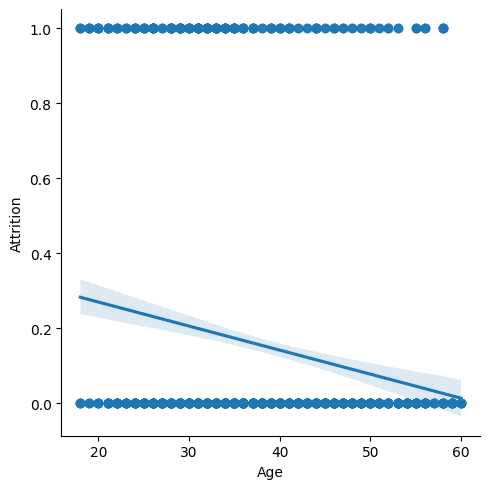

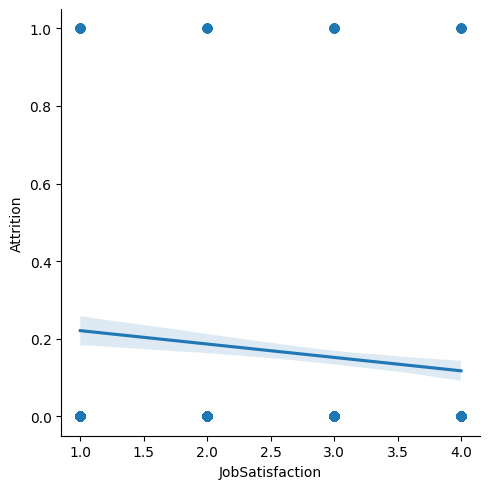

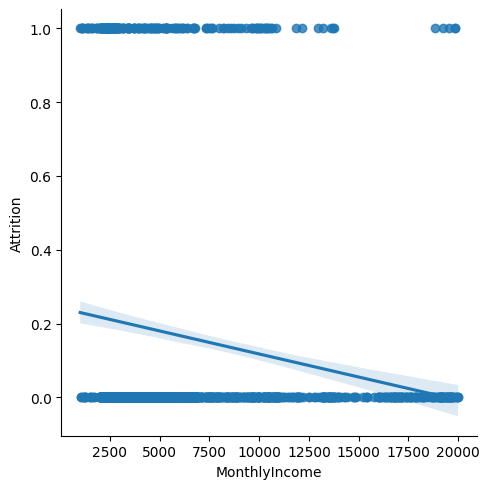

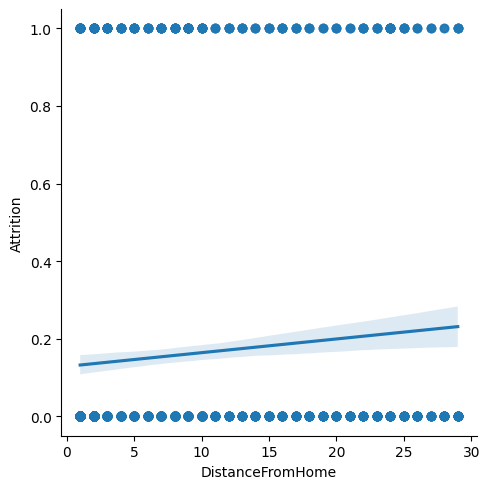

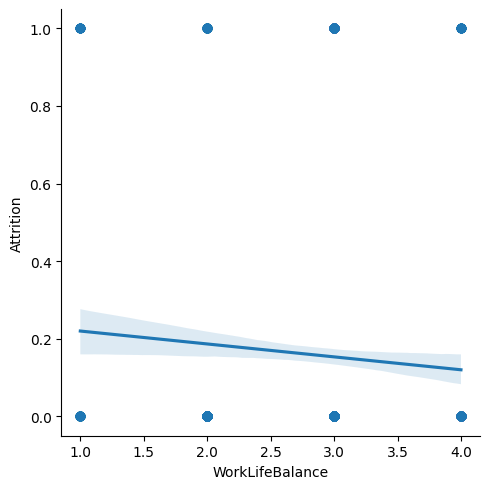

In [7]:

# 5)Create a list of your independent variables and use a loop to create a plot of each one against your dependent variable.  

# Converting 'Attrition' from categorical ('Yes'/'No') to numerical (1/0)
dataset['Attrition'] = dataset['Attrition'].map({'Yes': 1, 'No': 0})


y = dataset['Attrition'] #dependent variable
xvars = ['Age','JobSatisfaction','MonthlyIncome',
        'DistanceFromHome','WorkLifeBalance']
X = dataset[xvars] #independent variables

#Plotting each independent variable against the dependent variable
for i in xvars:
    sns.lmplot(x=i,y='Attrition',fit_reg=True,data=dataset)


In [11]:
dataset['WorkLifeBalance'].unique()
dataset['JobRole'].unique()

array(['Sales Executive', 'Research Scientist', 'Laboratory Technician',
       'Manufacturing Director', 'Healthcare Representative', 'Manager',
       'Sales Representative', 'Research Director', 'Human Resources'],
      dtype=object)

In [ ]:
# 6) Create three different linear regression models using different subsets of independent variables.  Print the regression results for each.
# def prepare_model_data(dependent_var, independent_vars):
#     try:
#         y = pd.Categorical(dataset[dependent_var]).codes
#         X = sm.add_constant(dataset[independent_vars].astype(float))
#         return y, X
#     except Exception as e:
#         print(f"Error preparing model data: {e}")
#         return None, None

# y1, X1 = prepare_model_data(dependent_var, ['Age', 'DailyRate'])
# model1 = sm.OLS(y1, X1).fit()
# print(model1.summary())

# y2, X2 = prepare_model_data(dependent_var, ['Age', 'MonthlyIncome'])
# model2 = sm.OLS(y2, X2).fit()
# print(model2.summary())

# y3, X3 = prepare_model_data(dependent_var, ['DailyRate', 'DistanceFromHome'])
# model3 = sm.OLS(y3, X3).fit()
# print(model3.summary())

#Add a constant to the independent variables data frame so that the regression includes an intercept term
# X = sm.add_constant(X)
# X.head()

# model1 = sm.OLS(y,X)
# results1 = model1.fit()
# results1.summary()

# y = dataset['Attrition']
# xvars = ['Age','JobSatisfaction','MonthlyIncome',
#         'DistanceFromHome','WorkLifeBalance']
# X = dataset[xvars]
# model2 = sm.OLS(y,X)
# results2 = model2.fit()
# summary2 = results2.summary()
# print(summary2)

# xvars=datasets['Age','BusinessTravel','DailyRate','Department','DistanceFromHome','Education',
#         'EducationField','EmployeeCount','EmployeeNumber','EnvironmentSatisfaction','Gender',
#          'HourlyRate','JobInvolvement','JobLevel','JobRole','JobSatisfaction','MaritalStatus',
#          'MonthlyIncome','MonthlyRate','NumCompaniesWorked','Over18','OverTime','PercentSalaryHike',
#          'PerformanceRating','RelationshipSatisfaction','StandardHours','StockOptionLevel','TotalWorkingYears',
#          'TrainingTimesLastYear','WorkLifeBalance','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion',
#          'YearsWithCurrManager'
#         ]

y = dataset['Attrition'] #dependent variable
xvars = ['Age','JobSatisfaction','MonthlyIncome',
        'DistanceFromHome','WorkLifeBalance']

model1 = sm.OLS.from_formula('Attrition ~ YearsWithCurrManager+Over18+TotalWorkingYears+vbnfmg,h/L:"', dataset)
results1 = model1.fit()
results1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Attrition   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     22.11
Date:                Mon, 16 Dec 2024   Prob (F-statistic):           5.26e-14
Time:                        16:01:15   Log-Likelihood:                -582.74
No. Observations:                1470   AIC:                             1173.
Df Residuals:                    1466   BIC:                             1195.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.2373      0.020     11.697      0.000       0.197       0.277
YearsWithCurrManager    -0.0103      0.003     -3.465      0.001      -0.016      -0.004
TotalWorkingYears       -0.0059      0.001     -4.370      0.000      -0.009      -0.003
DistanceFromHome         0.0036      0.001      3.129      0.002       0.001       0.006
==============================================================================
Omnibus:                      412.136   Durbin-Watson:                   1.931
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              830.525
Skew:                           1.728   Prob(JB):                    4.51e-181
Kurtosis:                       4.272   Cond. No.                         37.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [44]:
subset_1 = ['Age', 'MonthlyIncome','DistanceFromHome','JobSatisfaction','NumCompaniesWorked',
           'YearsAtCompany','WorkLifeBalance','EnvironmentSatisfaction','YearsAtCompany',
            'OverTime'
           ]
# Add constant term for intercept
X1 = sm.add_constant(dataset[subset_1]) 

model_1 = sm.OLS(y, X1).fit()
summary_1 = model_1.summary()
print(summary_1)

subset_2 = ['Age', 'JobSatisfaction', 'WorkLifeBalance']
X2 = sm.add_constant(dataset[subset_2])
model_2 = sm.OLS(y, X2).fit()



ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [36]:
# 7) Compare models using R^2, AIC, etc.
print("Model Comparison:")
print(f'Model 1: R^2={model1.rsquared}, AIC={model1.aic}')
print(f'Model 2: R^2={model2.rsquared}, AIC={model2.aic}')
print(f'Model 3: R^2={model3.rsquared}, AIC={model3.aic}')

Model Comparison:
Model 1: R^2=-inf, AIC=-98745.11289883025
Model 2: R^2=-inf, AIC=-88540.40610457376
Model 3: R^2=-inf, AIC=-98731.3847335565


In [13]:
# 8) Variance Inflation Factor (VIF)
X = dataset[independent_vars].astype(float)
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

           Variable       VIF
0               Age  8.223920
1         DailyRate  4.134255
2  DistanceFromHome  2.158669
3     MonthlyIncome  3.783878


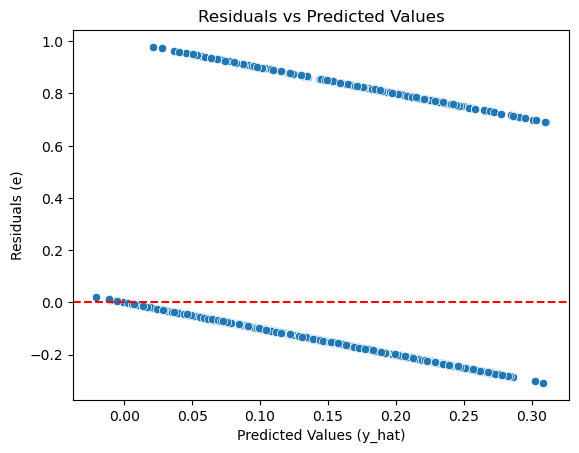

In [14]:
# 9) Predicted values and residuals
best_model = model1  # Example selection

y_hat = best_model.predict(X1)
e = y1 - y_hat

sns.scatterplot(x=y_hat, y=e)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values (y_hat)')
plt.ylabel('Residuals (e)')
plt.show()

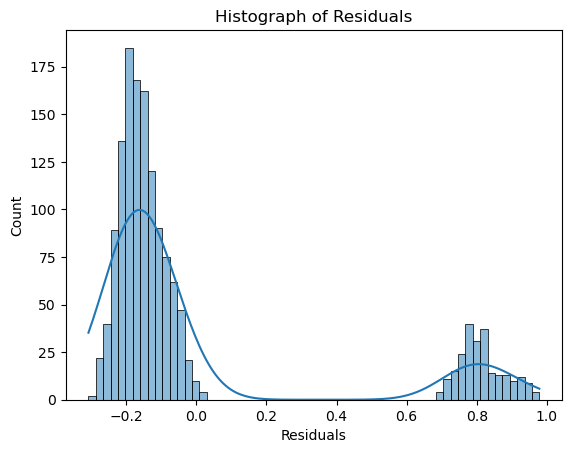

NameError: name 'normaltest' is not defined

In [16]:
# 10) Histogram of residuals
sns.histplot(e, kde=True)
plt.title('Histograph of Residuals')
plt.xlabel('Residuals')
plt.show()

stat, p = normaltest(e)
print(f'Normality test p-value: {p}')
if p > 0.05:
    print("Residuals appear to be normally distributed.")
else:
    print("Residuals do not appear to be normally distributed.")

In [17]:
# 11) Test for heteroskedasticity
_, pval, _, _ = het_breuschpagan(e, X1)
print(f'Breusch-Pagan test p-value: {pval}')
if pval > 0.05:
    print("No heteroskedasticity detected.")
else:
    print("Heteroskedasticity detected.")

Breusch-Pagan test p-value: 9.774248112145456e-08
Heteroskedasticity detected.


In [18]:
# 12) Standardized residuals
std_residuals = e / np.std(e)
outliers = np.abs(std_residuals) > 3
print(f'Number of outliers: {np.sum(outliers)}')

Number of outliers: 0


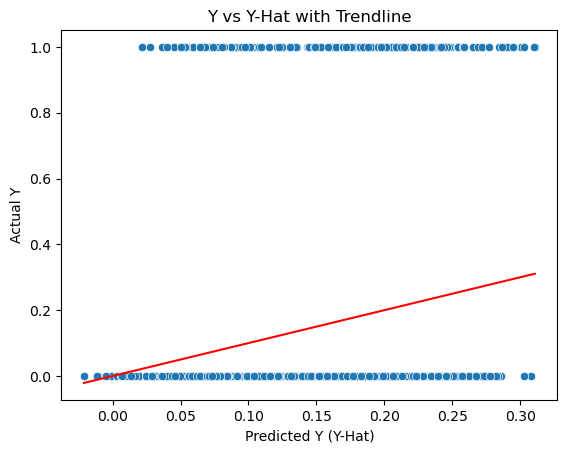

In [19]:
# 13) Scatterplot of Y vs Y-Hat
sns.scatterplot(x=y_hat, y=y1)
sns.lineplot(x=y_hat, y=y_hat, color='red')
plt.title('Y vs Y-Hat with Trendline')
plt.xlabel('Predicted Y (Y-Hat)')
plt.ylabel('Actual Y')
plt.show()


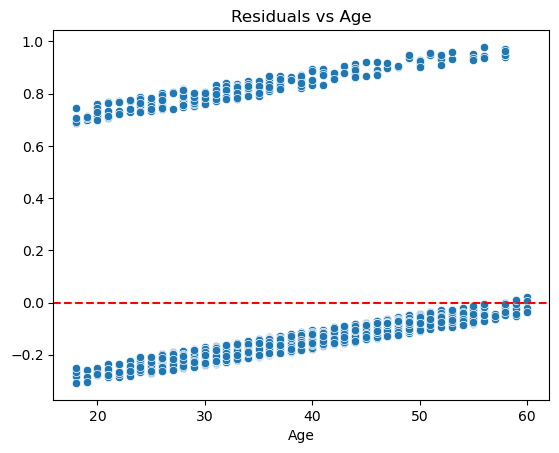

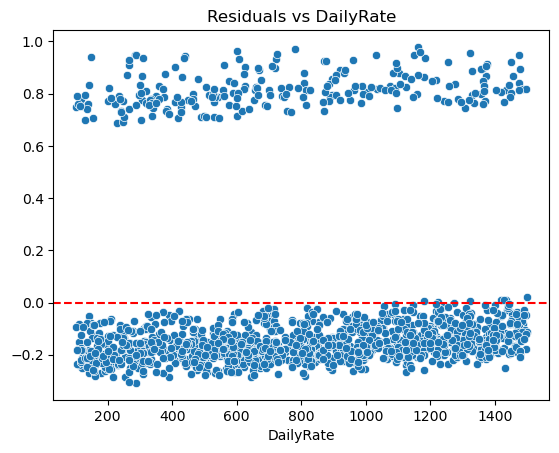

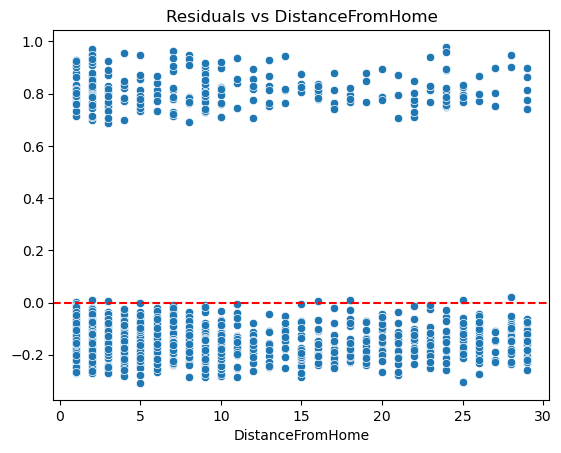

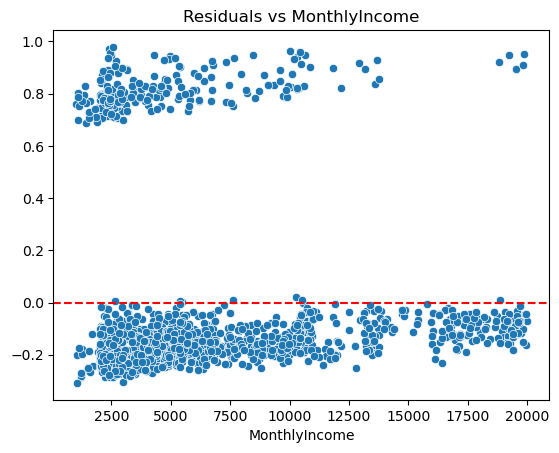

In [21]:
# 14) Residuals vs X-variables
for var in independent_vars:
    sns.scatterplot(x=dataset[var], y=e)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'Residuals vs {var}')
    plt.show()

In [23]:
# 15) Predictions for hypothetical observations
new_data = pd.DataFrame({
    'Age': [30, 40, 50, 60, 35],
    'DailyRate': [500, 700, 800, 900, 1000],
    'DistanceFromHome': [5, 10, 3, 8, 2],
    'MonthlyIncome': [4000, 6000, 7000, 9000, 4500]
})

# Adjust columns for the selected model (['Age', 'DailyRate'])
new_data = new_data[['Age', 'DailyRate']]
new_data = sm.add_constant(new_data)

predicted_y = best_model.predict(new_data)
print(predicted_y)

0    0.220605
1    0.146711
2    0.077828
3    0.008945
4    0.163616
dtype: float64
